In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [3]:
data = pd.read_csv("diabetes.csv")

In [4]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [5]:
print(data["Outcome"].value_counts())
print("Percentage\n")
print(data["Outcome"].value_counts(normalize=True)*100)

Outcome
0    500
1    268
Name: count, dtype: int64
Percentage

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in zero_cols:
    zeros = (data[col]==0).sum()
    perc = zeros/len(data) * 100
    print(f"{col:25s} : {zeros:3d} zeros, {perc:0.2f}%")
#

Glucose                   :   5 zeros, 0.65%
BloodPressure             :  35 zeros, 4.56%
SkinThickness             : 227 zeros, 29.56%
Insulin                   : 374 zeros, 48.70%
BMI                       :  11 zeros, 1.43%


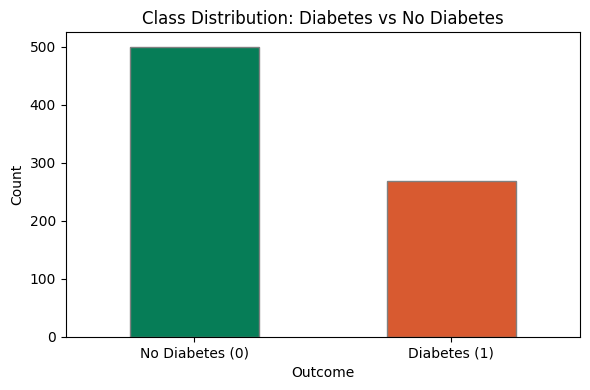

In [8]:
plt.figure(figsize=(6, 4))
data['Outcome'].value_counts().plot(kind='bar', color=["#067D57", '#D85A30'], edgecolor='Grey')
plt.title('Class Distribution: Diabetes vs No Diabetes')
plt.xticks([0, 1], ['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

<Axes: >

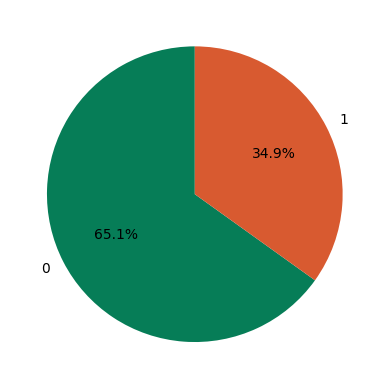

In [9]:
data['Outcome'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=["#067D57", '#D85A30'],startangle=90)


Text(0.5, 1.02, 'Feature Distributions by Outcome')

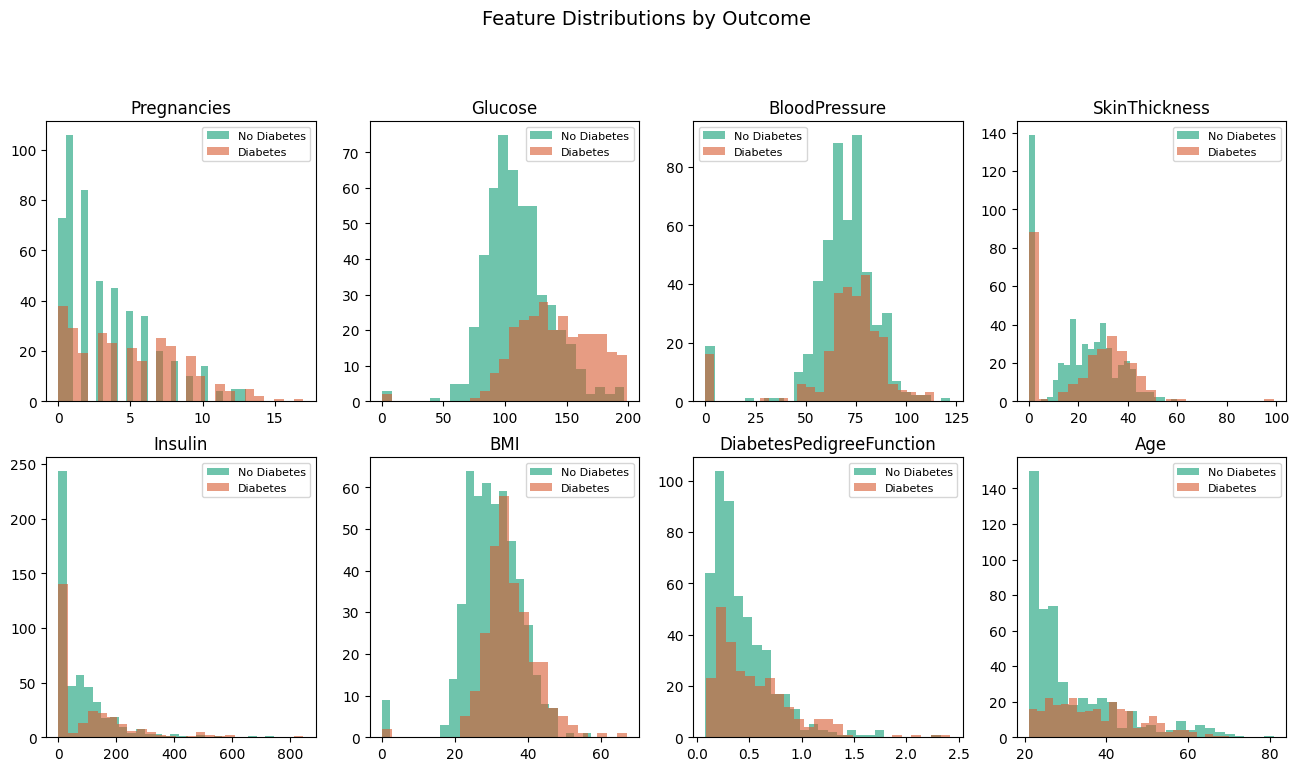

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

features = ['Pregnancies', 'Glucose', 'BloodPressure', "SkinThickness","Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

for i, feature in enumerate(features):
  axes[i].hist(data[data['Outcome'] == 0][feature], bins=25,
  alpha=0.6, color='#109E75', label='No Diabetes')
  axes[i].hist(data[data['Outcome'] == 1][feature], bins=25,
  alpha=0.6, color='#D85A30', label='Diabetes')
  axes[i].set_title(feature)
  axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Outcome', fontsize=14, y=1.02)

In [29]:
import seaborn as sns

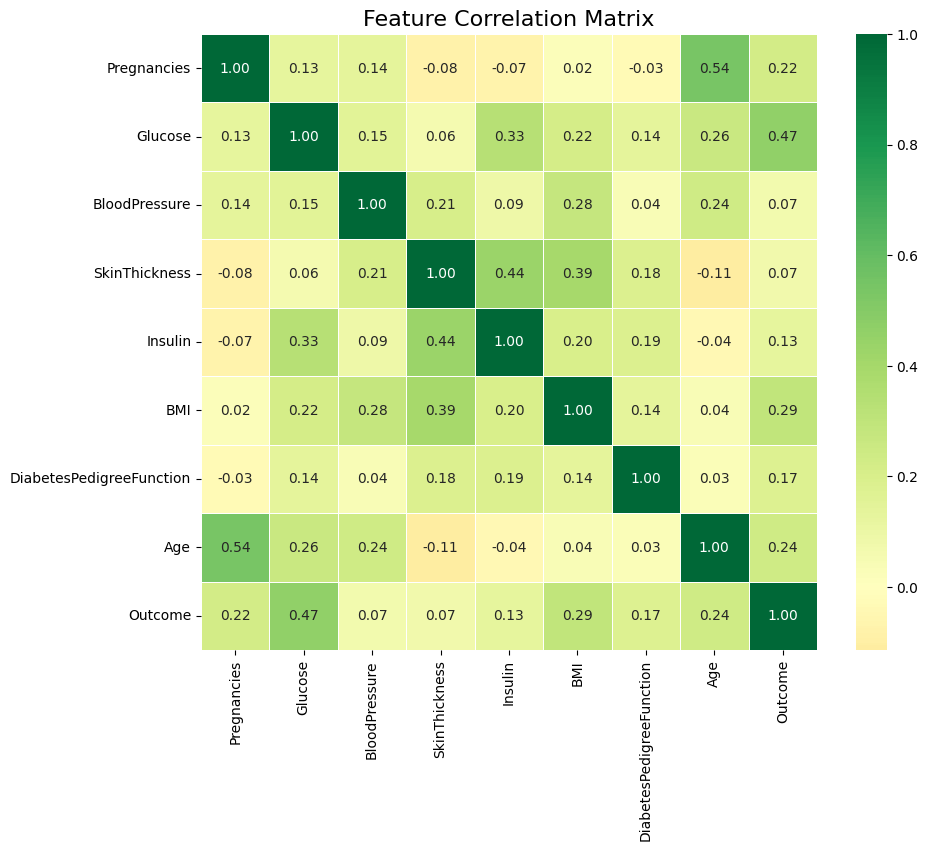

In [32]:
#heat map
corr = data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="RdYlGn",center=0,square = True,linewidth=0.5, fmt=".2f")
plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

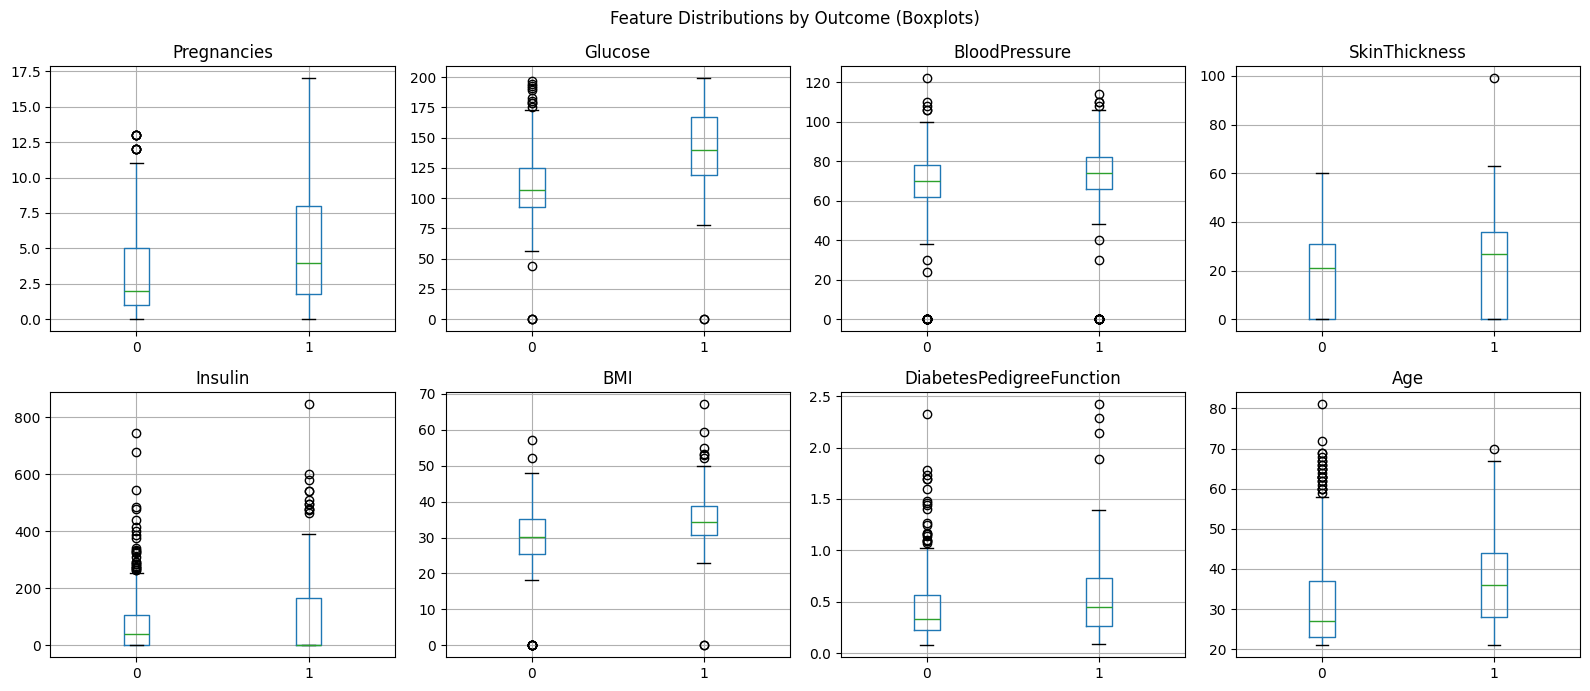

In [12]:
#Boxplots for outlier detection
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feature in enumerate(features):
    data.boxplot(column=feature, by='Outcome', ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel("")

plt.suptitle('Feature Distributions by Outcome (Boxplots)')
plt.tight_layout()

In [16]:
print(data.groupby('Outcome').mean().T)

Outcome                            0           1
Pregnancies                 3.298000    4.865672
Glucose                   109.980000  141.257463
BloodPressure              68.184000   70.824627
SkinThickness              19.664000   22.164179
Insulin                    68.792000  100.335821
BMI                        30.304200   35.142537
DiabetesPedigreeFunction    0.429734    0.550500
Age                        31.190000   37.067164


In [19]:
cols_to_replace = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols_to_replace:
    median = data[col].median()
    data[col] = data[col].replace(0, median)
    print(f"Replaced zeros in '{col}' with median value: {median}")
print(data[cols_to_replace].describe())


Replaced zeros in 'Glucose' with median value: 117.0
Replaced zeros in 'BloodPressure' with median value: 72.0
Replaced zeros in 'SkinThickness' with median value: 23.0
Replaced zeros in 'Insulin' with median value: 31.25
Replaced zeros in 'BMI' with median value: 32.0
          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  768.000000     768.000000     768.000000  768.000000  768.000000
mean   121.656250      72.386719      27.334635   94.652344   32.450911
std     30.438286      12.096642       9.229014  105.547598    6.875366
min     44.000000      24.000000       7.000000   14.000000   18.200000
25%     99.750000      64.000000      23.000000   30.500000   27.500000
50%    117.000000      72.000000      23.000000   31.250000   32.000000
75%    140.250000      80.000000      32.000000  127.250000   36.600000
max    199.000000     122.000000      99.000000  846.000000   67.100000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [30]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("X Shape:", X.shape
      , "\nY Shape:", y.shape   
      , "\nX Columns:", X.columns.tolist())

X Shape: (768, 8) 
Y Shape: (768,) 
X Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [48]:

model = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=4, min_samples_split=10, min_samples_leaf=5)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [47]:
# Predictions
y_pred = model.predict(X_test)
# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.79      0.84       100
           1       0.68      0.81      0.74        54

    accuracy                           0.80       154
   macro avg       0.78      0.80      0.79       154
weighted avg       0.81      0.80      0.80       154

Confusion Matrix:
 [[79 21]
 [10 44]]
Accuracy Score: 0.7987012987012987


[Text(0.5648148148148148, 0.9, 'Glucose <= 154.5\nentropy = 0.933\nsamples = 614\nvalue = [400, 214]\nclass = No Diabetes'),
 Text(0.2962962962962963, 0.7, 'BMI <= 26.75\nentropy = 0.818\nsamples = 515\nvalue = [384, 131]\nclass = No Diabetes'),
 Text(0.4305555555555555, 0.8, 'True  '),
 Text(0.14814814814814814, 0.5, 'Glucose <= 132.0\nentropy = 0.174\nsamples = 115\nvalue = [112, 3]\nclass = No Diabetes'),
 Text(0.07407407407407407, 0.3, 'DiabetesPedigreeFunction <= 0.675\nentropy = 0.079\nsamples = 102\nvalue = [101, 1]\nclass = No Diabetes'),
 Text(0.037037037037037035, 0.1, 'entropy = 0.0\nsamples = 86\nvalue = [86, 0]\nclass = No Diabetes'),
 Text(0.1111111111111111, 0.1, 'entropy = 0.337\nsamples = 16\nvalue = [15, 1]\nclass = No Diabetes'),
 Text(0.2222222222222222, 0.3, 'Insulin <= 45.25\nentropy = 0.619\nsamples = 13\nvalue = [11, 2]\nclass = No Diabetes'),
 Text(0.18518518518518517, 0.1, 'entropy = 0.918\nsamples = 6\nvalue = [4, 2]\nclass = No Diabetes'),
 Text(0.2592592592

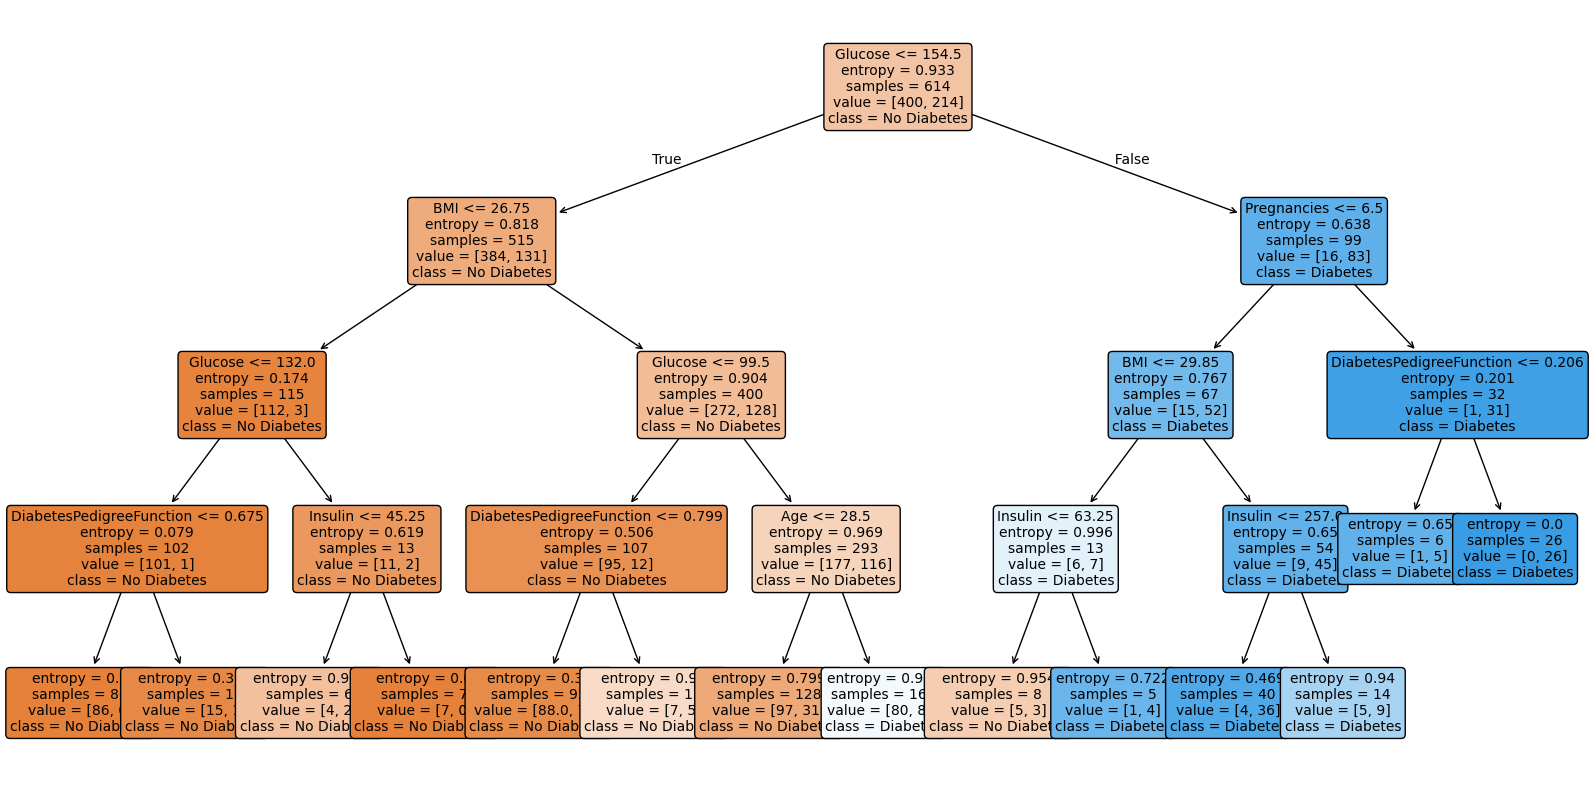

In [ ]:
#viualization of the tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, rounded=True, fontsize=10)


ROC AUC Score: 0.8210185185185186


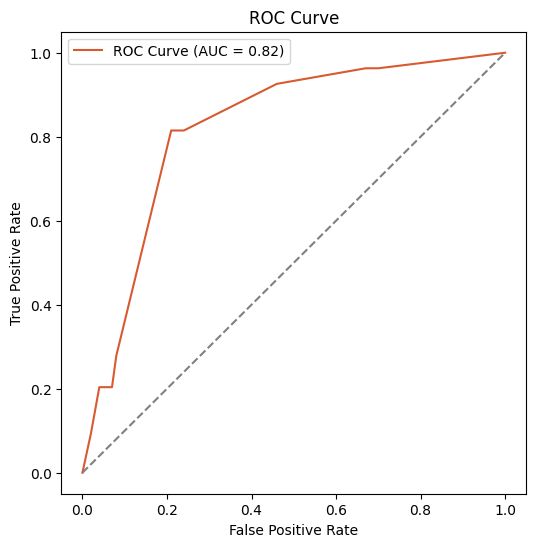

In [52]:
#full evaluation
from sklearn.metrics import roc_auc_score, roc_curve
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", auc)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='#D85A30', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()